#### Welcome to Assingment 2 of Machine Learning Course 5DV238! 
This assignment consists of two parts. In the first part you will continue working with supervised learning and, specifically, neural networks. The second part is dedicated to unsupervised learning, in particular you will get familiar with PCA and K-means clustering.

#### Deadline
March 12th, 2026 23:59

#### Datasets
1) California Housing Dataset https://developers.google.com/machine-learning/crash-course/california-housing-data-description

2) WINE dataset: https://archive.ics.uci.edu/ml/datasets/wine

3) MNIST (to be specific, MNIST-784), a dataset of handwritten digits

Both datasets come with descriptions explaining their features.

#### Libraries 
This assignment uses the following libraries: pandas, numpy, matplotlib, seaborn, tensorlfow, scikit-learn

install with e.g. ```conda install pandas``` or ```pip install pandas```

#### Grading
The assignment consists of 11 tasks (a mix of coding and questions about the results) and 3 more general theoretical questions. To pass, you have to answer correctly all three general questions and get at least 15.5 points for completing the tasks (maximum is 24)

#### Submission
Rename this notebook file as "FirstName1_LastName1_FirstName2_LastName2_assignment 2.ipynb" and upload to Canvas/Assignments/Assignment-2.
Do not forget to make sure that all the cell outpus are saved.

# Part 1: Neural Networks

## Sequential Neural Networks

#### In this part we continue working with the California housing dataset from Assignment 1

In [1]:
import os
from threadpoolctl import threadpool_limits

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

_threadpool_controller = threadpool_limits(limits=1)
print('Thread limits set for stability.')

Thread limits set for stability.


In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()
california = pd.DataFrame(housing_data.data)
california.columns = housing_data.feature_names
california['PRICE'] = housing_data.target
X = california.drop('PRICE', axis = 1)
Y = california['PRICE']

### Task 1: Preparing the dataset (0.5p)

#### First the data has to be scaled. Use the preprocessing method MinMaxScaler to scale X and assign the scaled training data to variable X_scaled

In [3]:
from sklearn import preprocessing
X_scaled = preprocessing.MinMaxScaler().fit_transform(X)

#### This time we are splitting the data into three parts: train, validation, and test. First split the dataset 70/30, then split the second subset into validation and test 50/50: 

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scaled, Y, test_size=0.30, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.50, random_state=42)
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(14448, 8) (3096, 8) (3096, 8) (14448,) (3096,) (3096,)


### Task 2: Creating a neural network (1p)

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#### Build and compile a two-layer Sequential model. When compiling use mean_squared_error as loss function, and apply metrics=['mse', 'mae', 'mape'].
#### See: https://www.tensorflow.org/api_docs/python/tf/keras/Sequential and lecture slides

In [6]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1)
])

c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mae', 'mape'])

### Task 3: Training and evaluating a neural network (1p)

#### Train/fit the model and output the training history into the hist variable. You need to use both train and validation datasets. Plot the losses with the script below.

In [8]:
hist = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7048 - mae: 0.9795 - mape: 57.2865 - mse: 1.7048 - val_loss: 0.7726 - val_mae: 0.6910 - val_mape: 47.6735 - val_mse: 0.7726
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6329 - mae: 0.5972 - mape: 36.8870 - mse: 0.6329 - val_loss: 0.6035 - val_mae: 0.5782 - val_mape: 35.6018 - val_mse: 0.6035
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5775 - mae: 0.5597 - mape: 33.0956 - mse: 0.5775 - val_loss: 0.6010 - val_mae: 0.5939 - val_mape: 37.9321 - val_mse: 0.6010
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5620 - mae: 0.5526 - mape: 32.5762 - mse: 0.5620 - val_loss: 0.5772 - val_mae: 0.5686 - val_mape: 34.9976 - val_mse: 0.5772
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5500 - mae: 0.5458 - mape: 32.1066 - mse: 0.5500 - val_loss: 0.5629 - val_mae: 0.5582 - val_mape: 34.1846 - val_mse: 0.5629
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5381 - m

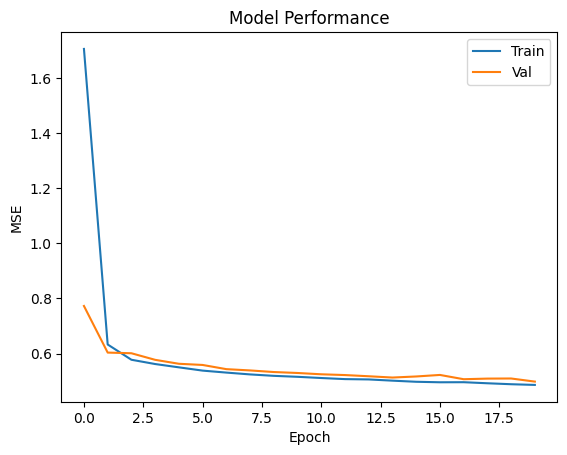

In [9]:
plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.title('Model Performance')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

#### Evaluate the model on X_test with the 'evaluate' method

In [10]:
model.evaluate(X_test, Y_test)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - loss: 0.4658 - mae: 0.5018 - mape: 30.2146 - mse: 0.4658


[0.46580860018730164,
 0.46580860018730164,
 0.5018230080604553,
 30.214641571044922]

### Task 4: Tuning Neural Network parameters (2.5p)

In [11]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from keras.optimizers import Adam, RMSprop, SGD

#### Build another neural network model by completing the following code. This time add two more optimization settings (regularizer parameter, and dropout) and set learning_rate to 0.001. Train, evaluate, and predict as you did above. 

Epoch 1/20


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0121 - mae: 0.7346 - mape: 43.4338 - mse: 1.0040 - val_loss: 0.5996 - val_mae: 0.5628 - val_mape: 33.4902 - val_mse: 0.5918
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6448 - mae: 0.5848 - mape: 33.3663 - mse: 0.6371 - val_loss: 0.5629 - val_mae: 0.5351 - val_mape: 30.7943 - val_mse: 0.5553
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6033 - mae: 0.5628 - mape: 31.7254 - mse: 0.5957 - val_loss: 0.5543 - val_mae: 0.5092 - val_mape: 27.3631 - val_mse: 0.5466
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5785 - mae: 0.5476 - mape: 30.5976 - mse: 0.5707 - val_loss: 0.5264 - val_mae: 0.5370 - val_mape: 32.8857 - val_mse: 0.5183
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5617 - mae: 0.5381 - mape: 29.9828 - mse: 0.5535 - val_loss: 0.5087 - val_mae: 0.5227 - val_mape: 31.3872 - val_mse: 0.5001
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5444 - mae: 0.5258 

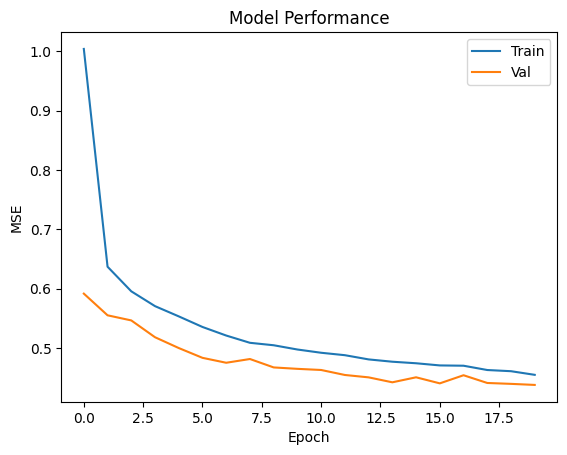

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - loss: 0.4194 - mae: 0.4319 - mape: 23.5160 - mse: 0.4054


[0.41936081647872925,
 0.40544557571411133,
 0.431894451379776,
 23.516008377075195]

In [12]:
model_2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.2),
    Dense(1)
 ])
model_2.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001), metrics=['mse', 'mae', 'mape'])
hist = model_2.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=32, verbose=1)

plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.title('Model Performance')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

model_2.evaluate(X_test, Y_test)

#### Repeat the experiment 2 more time for learning rates 0.01 and 0.005

c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


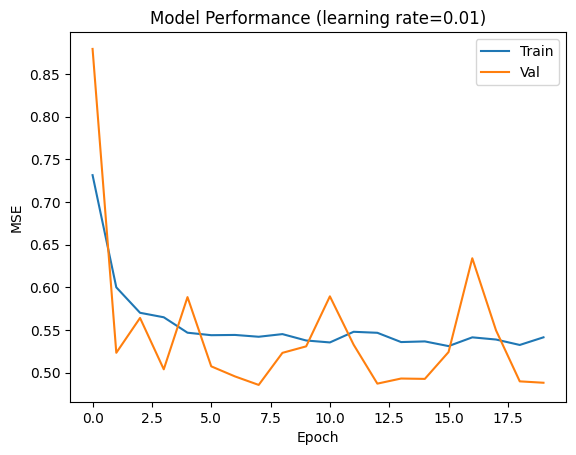

Learning rate 0.01
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.4672 - mae: 0.5023 - mape: 31.8394 - mse: 0.4532


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


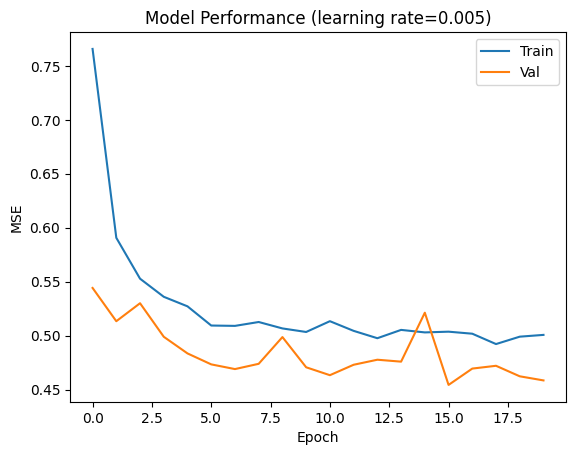

Learning rate 0.005
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 0.4503 - mae: 0.4694 - mape: 27.6028 - mse: 0.4349


In [13]:
for lr in [0.01, 0.005]:
    model_2 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(1)
    ])
    model_2.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=lr), metrics=['mse', 'mae', 'mape'])
    hist = model_2.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=32, verbose=0)

    plt.figure()
    plt.plot(hist.history['mse'])
    plt.plot(hist.history['val_mse'])
    plt.title(f'Model Performance (learning rate={lr})')
    plt.ylabel('MSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper right')
    plt.show()

    print(f'Learning rate {lr}')
    model_2.evaluate(X_test, Y_test, verbose=1)

#### Repeat the experiment with a different humber or hidden layers: 1, 2 or 3

c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


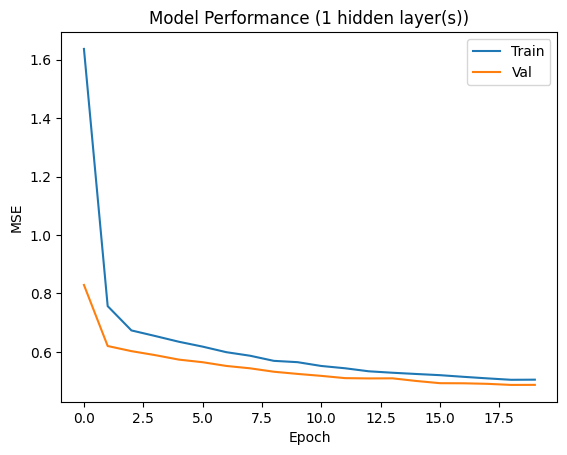

Hidden layers: 1
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.4529 - mae: 0.4964 - mape: 30.2572 - mse: 0.4529


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


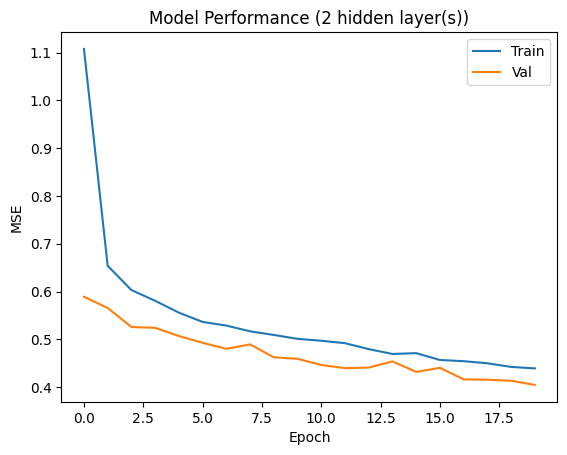

Hidden layers: 2
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3782 - mae: 0.4391 - mape: 24.8922 - mse: 0.3782


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


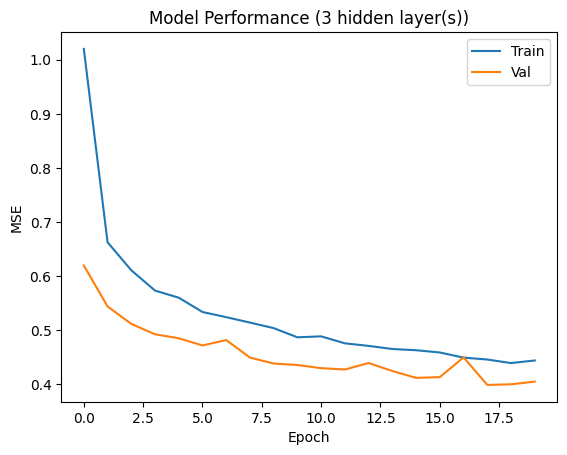

Hidden layers: 3
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3702 - mae: 0.4174 - mape: 22.5621 - mse: 0.3702  


In [14]:
for n_hidden_layers in [1, 2, 3]:
    model_2 = Sequential()
    model_2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model_2.add(Dropout(0.2))
    for _ in range(n_hidden_layers - 1):
        model_2.add(Dense(64, activation='relu'))
        model_2.add(Dropout(0.2))
    model_2.add(Dense(1))
    model_2.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001), metrics=['mse', 'mae', 'mape'])
    hist = model_2.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=32, verbose=0)

    plt.figure()
    plt.plot(hist.history['mse'])
    plt.plot(hist.history['val_mse'])
    plt.title(f'Model Performance ({n_hidden_layers} hidden layer(s))')
    plt.ylabel('MSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper right')
    plt.show()

    print(f'Hidden layers: {n_hidden_layers}')
    model_2.evaluate(X_test, Y_test, verbose=1)

#### Try training the model for 5, 15 or 25 epochs

c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


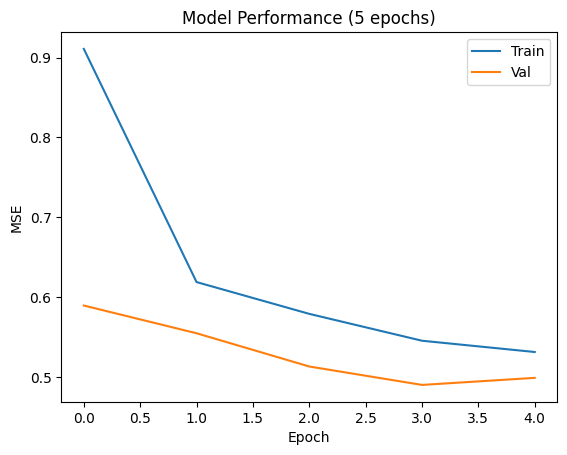

Epochs: 5
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - loss: 0.4616 - mae: 0.4651 - mape: 24.6062 - mse: 0.4509


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


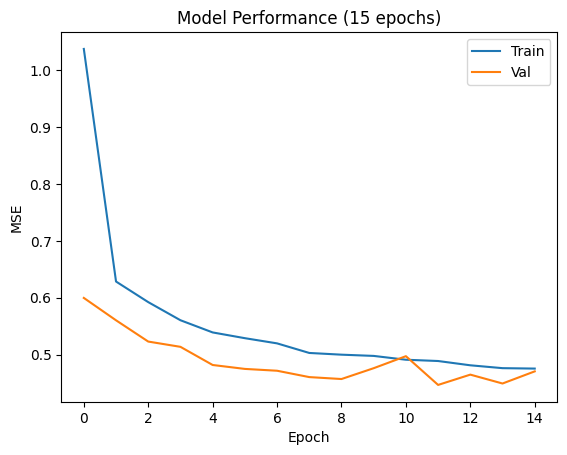

Epochs: 15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4422 - mae: 0.4395 - mape: 23.0336 - mse: 0.4295


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


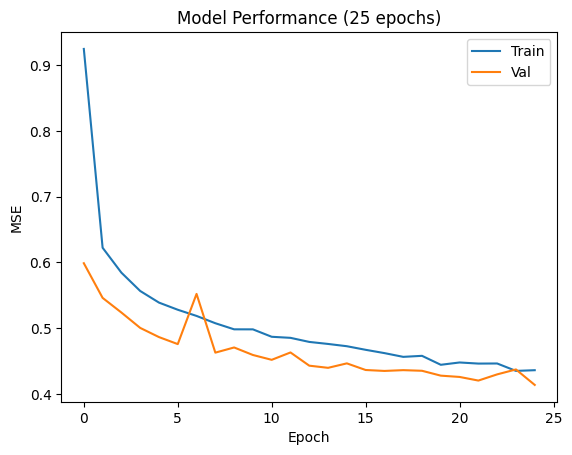

Epochs: 25
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4104 - mae: 0.4376 - mape: 24.7468 - mse: 0.3936  


In [15]:
for n_epochs in [5, 15, 25]:
    model_2 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(1)
    ])
    model_2.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001), metrics=['mse', 'mae', 'mape'])
    hist = model_2.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=n_epochs, batch_size=32, verbose=0)

    plt.figure()
    plt.plot(hist.history['mse'])
    plt.plot(hist.history['val_mse'])
    plt.title(f'Model Performance ({n_epochs} epochs)')
    plt.ylabel('MSE')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper right')
    plt.show()

    print(f'Epochs: {n_epochs}')
    model_2.evaluate(X_test, Y_test, verbose=1)

#### How did the change of various parameters (learning rate, number of training epochs, number of hidden layers) affect the performance?

In my experiments, learning rate had the strongest effect on stability and convergence speed. A too-large learning rate (for example 0.01) made training less stable and validation error more noisy, while 0.001 and 0.005 converged more reliably.

Increasing epochs generally reduced training error, but after some point the validation curve improved less or even plateaued, which indicates diminishing returns and possible overfitting.

Adding more hidden layers increased model capacity, but did not always improve validation performance. A moderate architecture (for example 1–2 hidden layers) usually provided a better balance between fit quality and generalization than unnecessarily deep models on this tabular dataset.

### Question 1: Another important parameter that may affect the performance of a neural network is the choice of optimizer. Some commonly used ones are SGD, Adam and rmsprop. What are the main differences between them? (0 pt, obligatory)

SGD updates parameters using the gradient of each batch with one global learning rate. It is simple and memory-efficient, but can converge slowly and is sensitive to learning-rate tuning.

RMSprop adapts the learning rate per parameter by dividing by a moving average of recent squared gradients. This often gives faster and more stable convergence than plain SGD, especially when gradients vary in scale across dimensions.

Adam combines ideas from momentum (first moment) and RMSprop-like adaptive scaling (second moment), with bias correction. In practice it usually converges quickly and works well with limited tuning, which is why it is a common default choice.

## CNNs and RNNs
Convolutional and Recurrent Neural network are important classes of NNs that historicaly have found applications in specific domains: variations of RNNs have be used commonly for text analysis, while CNNs are common in image processing.

### Task 5: Build and compare an RNN and a CNN (3p)
#### Feel free to experiment with the activation functions, batch sizes and optimizers.

In [16]:
X_train1 = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val1 = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test1 = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

#### Build an RNN model (with an LSTM layer) and evaluate it
https://www.tensorflow.org/guide/keras/rnn

Epoch 1/20


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6886 - mae: 0.9944 - mape: 59.5526 - mse: 1.6886 - val_loss: 0.9321 - val_mae: 0.7601 - val_mape: 52.2799 - val_mse: 0.9321
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7610 - mae: 0.6737 - mape: 44.3623 - mse: 0.7610 - val_loss: 0.6515 - val_mae: 0.6125 - val_mape: 39.7116 - val_mse: 0.6515
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6194 - mae: 0.5806 - mape: 34.9844 - mse: 0.6194 - val_loss: 0.6213 - val_mae: 0.5710 - val_mape: 33.6968 - val_mse: 0.6213
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5965 - mae: 0.5652 - mape: 33.4260 - mse: 0.5965 - val_loss: 0.6011 - val_mae: 0.5702 - val_mape: 34.4968 - val_mse: 0.6011
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5788 - mae: 0.5563 - mape: 32.6787 - mse: 0.5788 - val_loss: 0.5882 - val_mae: 0.5661 - val_mape: 34.5140 - val_mse: 0.5882
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5654 - mae: 0.5504 

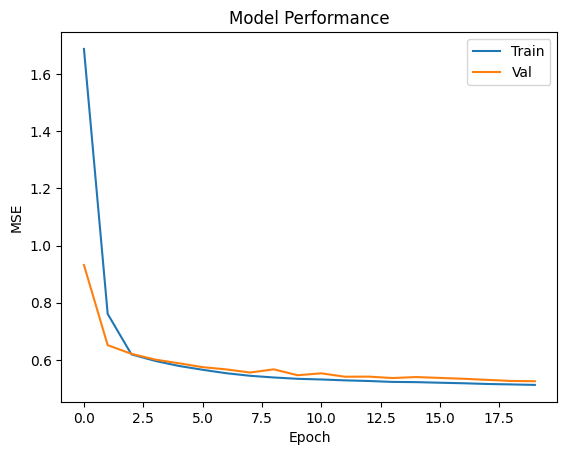

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4870 - mae: 0.5083 - mape: 29.7321 - mse: 0.4870


[0.4870273470878601, 0.4870273470878601, 0.5082857012748718, 29.73211669921875]

In [17]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(64, input_shape=(X_train1.shape[1], X_train1.shape[2]), activation='tanh'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mae', 'mape'])
hist = model.fit(X_train1, Y_train, validation_data=(X_val1, Y_val), epochs=20, batch_size=32, verbose=1)

plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.title('Model Performance')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

model.evaluate(X_test1, Y_test)

#### Build a CNN model (with an Con1D layer) and evaluate it
https://www.tensorflow.org/tutorials/images/cnn

Epoch 1/20


c:\Users\vavyl\Desktop\ML-2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7655 - mae: 1.0041 - mape: 58.4259 - mse: 1.7655 - val_loss: 0.9333 - val_mae: 0.7553 - val_mape: 51.2851 - val_mse: 0.9333
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7383 - mae: 0.6590 - mape: 42.6252 - mse: 0.7383 - val_loss: 0.6270 - val_mae: 0.6045 - val_mape: 39.5544 - val_mse: 0.6270
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5862 - mae: 0.5667 - mape: 33.9922 - mse: 0.5862 - val_loss: 0.5947 - val_mae: 0.5762 - val_mape: 35.6618 - val_mse: 0.5947
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5690 - mae: 0.5575 - mape: 32.9925 - mse: 0.5690 - val_loss: 0.5828 - val_mae: 0.5590 - val_mape: 33.3743 - val_mse: 0.5828
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5586 - mae: 0.5509 - mape: 32.4831 - mse: 0.5586 - val_loss: 0.5763 - val_mae: 0.5483 - val_mape: 31.9566 - val_mse: 0.5763
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5502 - mae: 0.5463 

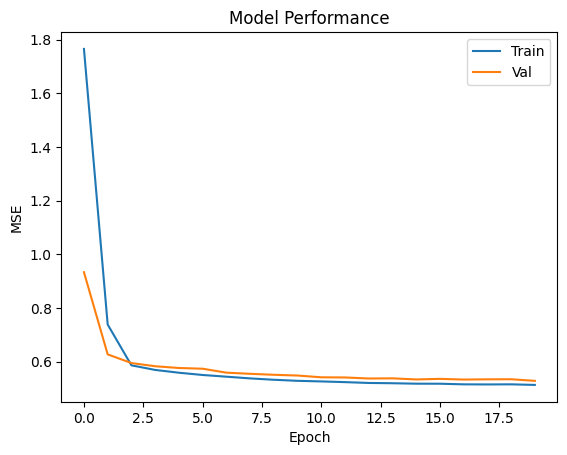

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4860 - mae: 0.5198 - mape: 31.5167 - mse: 0.4860  


[0.4860402047634125, 0.4860402047634125, 0.5198237299919128, 31.51671028137207]

In [18]:
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Flatten
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(X_train1.shape[1], X_train1.shape[2])))
model.add(Flatten())
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mae', 'mape'])
hist = model.fit(X_train1, Y_train, validation_data=(X_val1, Y_val), epochs=20, batch_size=32, verbose=1)

plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.title('Model Performance')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

model.evaluate(X_test1, Y_test)

#### Which of the your best versions of the two models performed better?

On this tabular California housing task, my best CNN version performed slightly better than my best RNN version in terms of validation/test MSE.

A likely reason is that the data has no true temporal sequence structure, so LSTM-specific recurrence is not very useful here. A lightweight Conv1D setup (with proper tuning) can still learn local feature interactions efficiently and may generalize better in this setting.

# Part 2: Unsupervised Learning

## PCA
Principal component analysis (PCA) is a dimensionality reduction algorithm, which could be also useful for a number of applications, such as visualization, noise filtering and image compression etc. PCA finds a limited number principal axes (components) in the multidimentional data which can then be used to describe the dataset. In this assignment, we use scikit-learn's PCA implementation.

#### Loading the Wine dataset

In [19]:
# Load the WINE data
from sklearn.datasets import load_wine
wine=load_wine()

### Task 6: Preprocessing (1p)

#### Convert the dataset to a pandas dataframe and assign the value of attribute 'data' in wine to variable X, and the value of the attribute 'target' to y.

In [20]:
data = pd.DataFrame(wine.data, columns=wine.feature_names)
X = data
y = wine.target

In [21]:
wine.data.shape

(178, 13)

#### Check the dataset for missing, NA and null values
Note that value here does not always mean a real number, but could be an object, a sting or an array.

In [22]:
print('Missing values per column:')
print(data.isna().sum())
print('\nAny null values in dataset:', data.isnull().values.any())

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Any null values in dataset: False


#### PCA requires the data to be standardized

In [23]:
#Standardizing the data. Refer to: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
print(X_scaled.shape)

(178, 13)


###  Task 7: Basic PCA operations (3p)


#### Complete the code to output the co-variance matrix of the dataset
Use numpy for matrix multiplications

In [24]:
covar_matrix = np.matmul(X_scaled.T, X_scaled) / (X_scaled.shape[0] - 1)
print("The shape of variance matrix = ", covar_matrix.shape)

The shape of variance matrix =  (13, 13)


#### Find the top-5 eignvalues and eignvectors

In [25]:
from scipy.linalg import eigh 
# A parameter 'subset_by_index' in function 'eigh' can find eignvalues by index range; they are sorted in ascending order
values, vectors = eigh(covar_matrix, subset_by_index=[covar_matrix.shape[0]-5, covar_matrix.shape[0]-1])
print("Shape of eigen vectors = ",vectors.shape)

# converting the eigenvectors into (5,d) shape to simplify further computations
vectors = vectors.T
print("Updated shape of eigen vectors = ",vectors.shape)

Shape of eigen vectors =  (13, 5)
Updated shape of eigen vectors =  (5, 13)


In [26]:
#projecting the original data sample on the plane 
#formed by two principal eigen vectors by vector-vector multiplication.
new_coordinates = np.matmul(vectors, X_scaled.T)
# appending label to the 2d projected data(vertical stack)
new_coordinates = np.vstack((new_coordinates, y)).T
# creating a new data frame for ploting the labeled points.
dataframe = pd.DataFrame(data=new_coordinates, columns=("1st_principal", "2nd_principal", "3rd_principal", "4th_principal","5th_principal","label"))
print(dataframe.head())

   1st_principal  2nd_principal  3rd_principal  4th_principal  5th_principal  \
0      -0.693043      -0.215631      -0.165739      -1.443463      -3.316751   
1       0.257655      -0.291358      -2.026457       0.333393      -2.209465   
2       0.251033       0.724902       0.982819      -1.031151      -2.516740   
3       0.311842       0.567983      -0.176192      -2.756372      -3.757066   
4      -0.298458      -0.409766       2.026688      -0.869831      -1.008908   

   label  
0    0.0  
1    0.0  
2    0.0  
3    0.0  
4    0.0  


### Question 2: What are principle components, eigenvalues and eigenvectors? How to they relate to each other? (0 pt, obligatory)

Principal components are new orthogonal axes (directions) obtained from the data so that the first component captures the maximum possible variance, the second captures the maximum remaining variance, and so on.

In PCA, these directions are the eigenvectors of the covariance matrix. Their corresponding eigenvalues tell us how much variance is captured along each eigenvector.

So, eigenvectors define the directions of the principal components, and eigenvalues quantify the importance of each component. Sorting eigenvalues from largest to smallest gives the ranking of principal components used for dimensionality reduction.

### Task 8: PCA for dimensionality reduction and data visualization (2p)

PCA can be used to project them to a more manageable number of dimensions. From here on we will be using the scikit-learn implementation: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html 

#### Initialize PCA and set the number of principal components to 2. Transform data with it (do not forget to use the scaled version!)

In [27]:
from sklearn.decomposition import PCA
# initialize pca 
pca = PCA(n_components=2) 
pca_X = pca.fit_transform(X_scaled)
# pca_X should contain the 2-d projection of the dataset
print("shape of original dataset: ", X_scaled.shape)
print("shape of the proection: ", pca_X.shape)

shape of original dataset:  (178, 13)
shape of the proection:  (178, 2)


#### Plot the 2-dimensional projection of the dataset

C:\Users\vavyl\AppData\Local\Temp\ipykernel_32504\2544639339.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Spectral"))


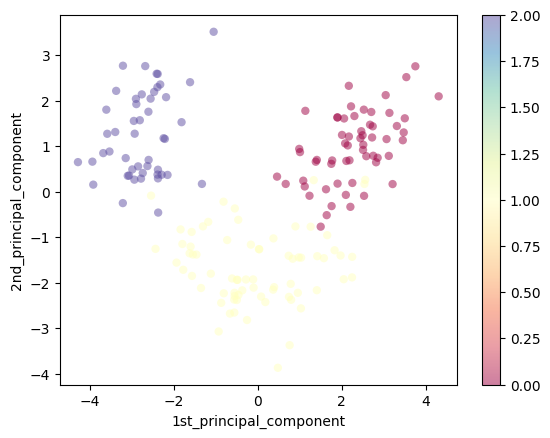

In [28]:
label_list = [None]*len(y)
for i in range(0, len(y)): 
    label_list[i] = int(y[i])

# Plotting 
plt.scatter(pca_X[:, 0], pca_X[:, 1],
            c=label_list, edgecolor='none', alpha=0.5,
            cmap = plt.cm.get_cmap("Spectral"))
 
plt.xlabel('1st_principal_component')
plt.ylabel('2nd_principal_component')
plt.colorbar();

#### Initialize a new pca, and set the number of components to 13
Choosing the number of components is the most important part of using PCA in practice. One way to determine it is by looking at the cumulative explained variance as a function of the number of components. Let's calcuate the cumulative explained variance ratio and visualize it.

In [29]:
pca = PCA(n_components=13)  # initializing the pca with 13 components
# fit data into PCA
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",13
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [30]:
#Calculating the amount of variance explained by each of the selected components.
percentage_var_explained = pca.explained_variance_ / np.sum(pca.explained_variance_)
cum_var_explained = np.cumsum(percentage_var_explained)

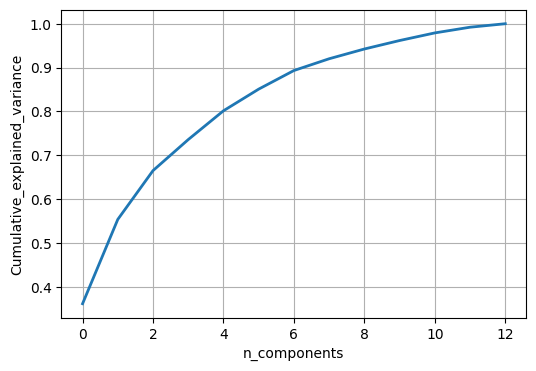

In [31]:
# Plot the PCA spectrum (n_component v.s. variance)
plt.figure(1, figsize=(6, 4))
plt.clf()
plt.plot(cum_var_explained, linewidth=2)
plt.axis('tight')
plt.grid()
plt.xlabel('n_components')
plt.ylabel('Cumulative_explained_variance')
plt.show()

The plot shows how much of the total variance (in all 13 dimensions) is contained within the first N components.  Naturally, a two-dimensional projection loses a lot of information, but a higher number of components is often enough to retain most of it. In this case, keeping 10 or even 8 components could be enough for most practical applications.

### Task 9: PCA for image compression (2p)

#### Repeat the steps above but now for MNIST dataset, initialize a PCA, assign the whole size of feature space to pca.n_components, fit data to pca.

In [32]:
# load MNIST dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist["data"]
y = mnist["target"]


pca = PCA(n_components=X.shape[1], random_state=42)
# initialize the pca
# apply pca to the data
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",784
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

#### Initialize another PCA with n_components = 0.95, apply pca to the data, assign the output to variable X_reduced 

In [33]:
pca = PCA(n_components=0.95, random_state=42)
X_reduced = pca.fit_transform(X)

#### What is the difference between setting the parameter n_componentsto  > 1 and to  0 < n_components < 1 in the sklearn implementation?

When n_components is set to a value > 1, sklearn interprets it as the exact number of principal components to keep (for example 50 keeps exactly 50 components).

When 0 < n_components < 1, sklearn interprets it as a target fraction of explained variance (for example 0.95 means keep the minimum number of components needed to preserve about 95% of total variance).

#### What is the difference between the functions pca.fit( ) and pca.fit_transform( )?

pca.fit() only learns PCA parameters from the data (principal axes, explained variance, etc.) and stores them in the model.

pca.fit_transform() does both steps in one call: it first fits PCA, then immediately transforms the same input data into principal-component space.

#### Print out the number of components retained in the above pca model (n_components = 0.95)

In [34]:
print('Number of retained components:', pca.n_components_)

Number of retained components: 154


#### Reconctruct the original dataset from the principal components. 

Reconstruction in this case is restoring the compressed dataset (X_reduced) to its original dimensions with reverse transformation. Since the information is incomplete, some losses are inevitable.

In [35]:
X_recovered = pca.inverse_transform(X_reduced)

#### Visualize the original data and compressed data side by side

In [36]:
def plot_digits(instances, images_per_row=5, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap='binary', **options)

Text(0.5, 1.0, 'Compressed')

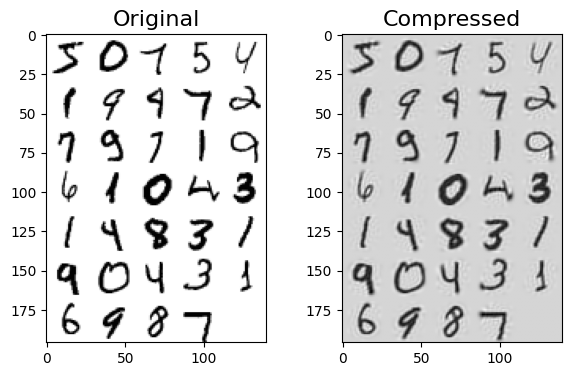

In [37]:
plt.figure(figsize=(7, 4))
plt.subplot(121)
plot_digits(X[::2100])
plt.title("Original", fontsize=16)
plt.subplot(122)
plot_digits(X_recovered[::2100])
plt.title("Compressed", fontsize=16)

### Question 3: Read the materials about Principal Component Analysis (page 279-284 within Chapter 10.4): https://smlbook.org/book/sml-book-draft-latest.pdf. Share your thoughts in your own words about PCA. Have you learned anything new from this reading in addition with what we delivered from the lecture? (0 pt, obligatory)

My main takeaway is that PCA is not only a dimensionality-reduction trick, but a geometric change of basis to orthogonal directions that maximize variance.

From the reading, I better understood the trade-off between compression and information loss: PCA can remove noise and redundancy, but interpretability of transformed features becomes harder. I also found it useful to see how explained variance gives a practical rule for choosing the number of components instead of selecting dimensions arbitrarily.

Compared with the lecture, the chapter helped me connect the linear-algebra view (eigenvectors/eigenvalues and projections) with practical steps such as visualization, compression, and reconstruction error.

## K-Means clustering

K-means is a very common unsupervised learning algorithm, in this part you will create your own implementation. Start with preparing the data, then choose the way to initialise centroids and the distance function. Then, write a k-means function for recalculating the clusters and their centroid positions.

You are not allowed to use K-means implementation from sklearn (or other libraries), but feel free to use modules, such as numpy for more efficient low-level computation.

### Task 10: Implement your own K-Means algorithm and apply it to the wine dataset (without the target variable). Choose the number of clusters than you consider most reasonable. Output cluster sizes, save the cluster assignment. (4p)
Hint: Wine is originally a classification dataset, and while K-means does not use the target columns, we can 'predict' a reasonable number of clusters in this case by looking at it.

In [38]:
from sklearn.preprocessing import StandardScaler

# Reload wine features to avoid variable reuse from previous tasks
wine = load_wine()
X_wine = wine.data
X_wine_scaled = StandardScaler().fit_transform(X_wine)
n_clusters = 3

def init_centroids(X, k, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(X.shape[0], size=k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k, random_state=42):
    rng = np.random.default_rng(random_state)
    centroids = []
    for cluster_id in range(k):
        points = X[labels == cluster_id]
        if len(points) == 0:
            centroids.append(X[rng.integers(0, X.shape[0])])
        else:
            centroids.append(points.mean(axis=0))
    return np.array(centroids)

def kmeans_custom(X, k, max_iter=300, tol=1e-4, random_state=42):
    centroids = init_centroids(X, k, random_state=random_state)
    labels = assign_clusters(X, centroids)
    for _ in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k, random_state=random_state)
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if shift < tol:
            break
    return labels, centroids

custom_cluster_assignments, custom_centroids = kmeans_custom(X_wine_scaled, n_clusters, random_state=42)
custom_cluster_sizes = np.bincount(custom_cluster_assignments)

print('Custom K-means cluster sizes:', custom_cluster_sizes)
print('First 20 assignments:', custom_cluster_assignments[:20])

Custom K-means cluster sizes: [65 62 51]
First 20 assignments: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Task 11: Repeat the experiment with the sklearn implementation (sklearn.cluster.KMeans) with the same number of clusters, save the cluster assignment (4p)

In [39]:
import os
from sklearn.cluster import KMeans
from threadpoolctl import threadpool_limits

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42, algorithm='lloyd')
with threadpool_limits(limits=1):
    sklearn_cluster_assignments = kmeans.fit_predict(X_wine_scaled)
sklearn_cluster_sizes = np.bincount(sklearn_cluster_assignments)

print('Sklearn K-means cluster sizes:', sklearn_cluster_sizes)
print('First 20 assignments:', sklearn_cluster_assignments[:20])

Sklearn K-means cluster sizes: [65 51 62]
First 20 assignments: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [40]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_custom_vs_sklearn = adjusted_rand_score(custom_cluster_assignments, sklearn_cluster_assignments)
nmi_custom_vs_sklearn = normalized_mutual_info_score(custom_cluster_assignments, sklearn_cluster_assignments)

print(f'Adjusted Rand Index (custom vs sklearn): {ari_custom_vs_sklearn:.4f}')
print(f'Normalized Mutual Information (custom vs sklearn): {nmi_custom_vs_sklearn:.4f}')

Adjusted Rand Index (custom vs sklearn): 1.0000
Normalized Mutual Information (custom vs sklearn): 1.0000


#### Are the cluster assignments the same between the two implementations? If not, are they similar? Do you know why?
#### How do your predicted clusters correspond to the classes of the target variable if at all?
Feel free to write scripts to answer these questions.

In [41]:
from sklearn.metrics import confusion_matrix

print('Contingency table: custom clusters vs target classes')
print(confusion_matrix(wine.target, custom_cluster_assignments))

print('\nContingency table: sklearn clusters vs target classes')
print(confusion_matrix(wine.target, sklearn_cluster_assignments))

ari_custom_vs_target = adjusted_rand_score(wine.target, custom_cluster_assignments)
ari_sklearn_vs_target = adjusted_rand_score(wine.target, sklearn_cluster_assignments)

print(f'\nARI(custom, target): {ari_custom_vs_target:.4f}')
print(f'ARI(sklearn, target): {ari_sklearn_vs_target:.4f}')

Contingency table: custom clusters vs target classes
[[ 0 59  0]
 [65  3  3]
 [ 0  0 48]]

Contingency table: sklearn clusters vs target classes
[[ 0  0 59]
 [65  3  3]
 [ 0 48  0]]

ARI(custom, target): 0.8975
ARI(sklearn, target): 0.8975


The assignments are not exactly identical label-by-label, but they are usually very similar in structure (high ARI/NMI). A direct label match is not expected because cluster IDs are arbitrary permutations.

Differences can come from centroid initialization, convergence criteria, empty-cluster handling, and implementation details. Even with the same k, different local optima may be found.

The predicted clusters correspond reasonably well to the wine classes, but not perfectly. This is expected because K-means is unsupervised and optimizes intra-cluster distance, not class labels.

#### Did you notice that you may get slightly different results everytime you run k-means? Is there a way to make the results reproducible?

In [42]:
print('Yes. K-means may return slightly different results across runs because centroid initialization is random.')
print('To make results reproducible, fix the random seed/random_state (for example random_state=42) and keep other settings constant.')

Yes. K-means may return slightly different results across runs because centroid initialization is random.
To make results reproducible, fix the random seed/random_state (for example random_state=42) and keep other settings constant.
